In [3]:
import pandas as pd

file_path = r"D:\22DKHA1\project\projeet 2\P2_Youtube_VideosVI.csv"
df = pd.read_csv(file_path)

print("Số dòng ban đầu:", len(df))
print("Các cột có trong file:", list(df.columns))
df.head(3)


Số dòng ban đầu: 9999
Các cột có trong file: ['video_id', 'title', 'description', 'published_at', 'channel', 'category_id', 'tags', 'view_count', 'like_count', 'comment_count']


,video_id,title,description,published_at,channel,category_id,tags,view_count,like_count,comment_count
0,DtXSB9qOjgM,Hướng Dẫn chậm 4 bước CHA CHA CHA cơ bản cho n...,💥💥💥ĐÂY LÀ LINK VIDEO RÁP ĐỘNG TÁC VỚI NHẠC: 💥 ...,2019-04-08T07:27:25Z,Zumba LeO,26,zumbafitness|dance|zumbaleo,10201605,58535.0,1499.0
1,sTnAFuyfY34,HƯỚNG DẪN CHẬM NHẢY KHIÊU VŨ BACHATA [ Hướng D...,Khiêu vũ bachata [ Hướng Dẫn Khiêu Vũ - Dân Vũ...,2024-09-01T10:30:19Z,Mão Phượng Dancesport,22,Dân Vũ|Khiêu Vũ|Hướng Dẫn Khiêu Vũ Dân Vũ Cho ...,46983,190.0,4.0
2,hs4i-SSN3Rw,Hướng dẫn đi vệ sinh đúng cách #funny #review ...,NaN,2025-07-26T08:37:26Z,Chuyện Chị Em,22,NaN,12448877,44724.0,154.0


In [4]:
import re
from langdetect import detect

# Giữ cột cần thiết
df = df[["title", "description", "category_id"]].copy()
df = df.dropna(subset=["description"])
df = df[df["description"].astype(str).str.len() >= 20]

# Làm sạch
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"#\w+|@\w+", "", text)
    text = re.sub(r"[\U00010000-\U0010ffff]", "", text)
    text = re.sub(r"[^a-zA-ZÀ-ỹ0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["description"].apply(clean_text)

# Chỉ giữ mô tả tiếng Việt
def is_vietnamese(text):
    try:
        return detect(text) == "vi"
    except:
        return False

df = df[df["clean_text"].apply(is_vietnamese)]
print("Sau khi lọc tiếng Việt:", len(df))
df.head(3)


Sau khi lọc tiếng Việt: 7636


,title,description,category_id,clean_text
0,Hướng Dẫn chậm 4 bước CHA CHA CHA cơ bản cho n...,💥💥💥ĐÂY LÀ LINK VIDEO RÁP ĐỘNG TÁC VỚI NHẠC: 💥 ...,26,đây là link video ráp động tác với nhạc em lại...
1,HƯỚNG DẪN CHẬM NHẢY KHIÊU VŨ BACHATA [ Hướng D...,Khiêu vũ bachata [ Hướng Dẫn Khiêu Vũ - Dân Vũ...,22,khiêu vũ bachata hướng dẫn khiêu vũ dân vũ cho...
4,Hướng Dẫn Ăn Chân Gà Chanh Sao Cho Đúng Cách! ...,Hướng Dẫn Ăn Chân Gà Chanh Sao Cho Đúng Cách! ...,22,hướng dẫn ăn chân gà chanh sao cho đúng cách t...


Sau khi tiền xử lý, dữ liệu được chuyển về dạng token hóa (tokenized_text) để phục vụ cho quá trình trích xuất đặc trưng và huấn luyện mô hình. Đây là định dạng tối ưu cho mô hình học máy nhưng không dễ hiểu với con người

In [5]:
from underthesea import word_tokenize

# Tách từ
df["tokenized_text"] = df["clean_text"].apply(lambda x: word_tokenize(x, format="text"))

# Đọc stopwords
stopword_path = r"D:\22DKHA1\project\projeet 2\vietnamese-stopwords-dash.txt"
with open(stopword_path, "r", encoding="utf-8") as f:
    stopwords = set(line.strip() for line in f if line.strip() != "")

# Stopwords mở rộng
extra_stopwords = {
    "kênh", "video", "đăng_ký", "youtube", "facebook", "com",
    "bản_quyền", "copyright", "liên_hệ", "email", "hotline",
    "website", "click", "subscribe", "xem", "theo_dõi",
    "1", "2", "3", "00", "01", "02","tiktok", "fanpage", "reup", "by", "h", "5",
    "link", "full", "clip", "shorts", "xem", "xem_ngay", 
    "đừng", "thông_tin", "cập_nhật", "like", "share", "24", "10", "4", "5", "00", "01", "02",
    "03", "04", "07", "not", "by", "tv", "official", "live", "news", "the", "of","nội_dung", "ủng_hộ", "quên", 
    "đi", "like", "share", "comment","giúp", "vui_lòng", "2025","việt_nam", "thế_giới", "hôm_nay", "chính_thức"
}
stopwords.update(extra_stopwords)

# Loại stopword
def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in stopwords])

df["tokenized_text"] = df["tokenized_text"].apply(remove_stopwords)
df = df[df["tokenized_text"].str.strip() != ""]
df = df.drop_duplicates(subset=["tokenized_text"])

print("Sau khi làm sạch:", len(df))
df.head(3)


c:\Users\NAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sau khi làm sạch: 6749


,title,description,category_id,clean_text,tokenized_text
0,Hướng Dẫn chậm 4 bước CHA CHA CHA cơ bản cho n...,💥💥💥ĐÂY LÀ LINK VIDEO RÁP ĐỘNG TÁC VỚI NHẠC: 💥 ...,26,đây là link video ráp động tác với nhạc em lại...,ráp_động_tác nhạc hiện tuyển_sinh lớp nhảy lớp...
1,HƯỚNG DẪN CHẬM NHẢY KHIÊU VŨ BACHATA [ Hướng D...,Khiêu vũ bachata [ Hướng Dẫn Khiêu Vũ - Dân Vũ...,22,khiêu vũ bachata hướng dẫn khiêu vũ dân vũ cho...,khiêu vũ_bachata hướng_dẫn khiêu_vũ dân_vũ tập
4,Hướng Dẫn Ăn Chân Gà Chanh Sao Cho Đúng Cách! ...,Hướng Dẫn Ăn Chân Gà Chanh Sao Cho Đúng Cách! ...,22,hướng dẫn ăn chân gà chanh sao cho đúng cách t...,hướng_dẫn chân gà chanh tuyển_tập tạp_hóa đồ_ă...


In [6]:
from collections import Counter

# Tách toàn bộ các từ trong cột tokenized_text
all_words = " ".join(df["tokenized_text"]).split()

#  Số lượng từ vựng duy nhất
unique_vocab = len(set(all_words))
print("Số lượng từ vựng duy nhất:", unique_vocab)

#  Độ dài mô tả trung bình (số từ mỗi mô tả)
avg_len = df["tokenized_text"].apply(lambda x: len(str(x).split())).mean()
print("Độ dài mô tả trung bình:", round(avg_len, 2))


Số lượng từ vựng duy nhất: 37196
Độ dài mô tả trung bình: 59.48


15 từ phổ biến nhất: [('tin_tức', 3229), ('phim', 2910), ('bóng_đá', 1634), ('review', 1604), ('công_nghệ', 1403), ('thời_sự', 1330), ('hướng_dẫn', 1137), ('điện_thoại', 1123), ('quốc_tế', 1045), ('nga', 1038), ('hàng', 1030), ('giá', 1011), ('du_lịch', 980), ('giải_trí', 965), ('hấp_dẫn', 960)]


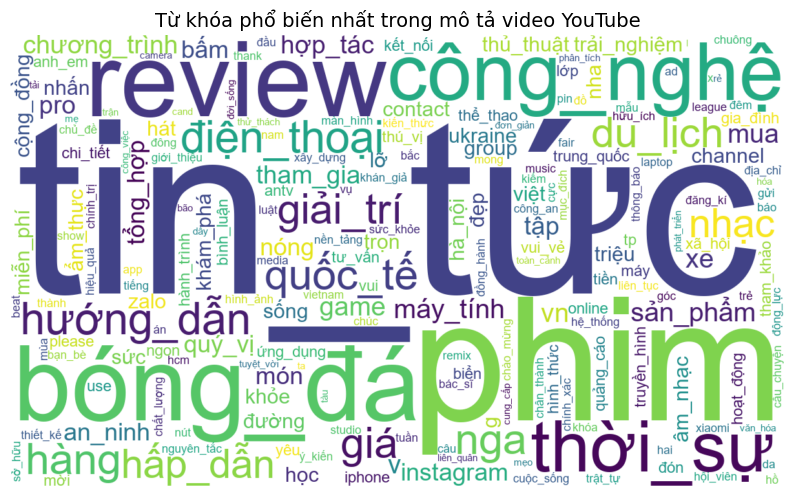

In [ ]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Top 15 từ phổ biến
words = " ".join(df["tokenized_text"]).split()
print("15 từ phổ biến nhất:", Counter(words).most_common(15))

# WordCloud tổng thể
text = " ".join(df["tokenized_text"])
wc = WordCloud(width=1200, height=700, background_color="white", font_path="arial.ttf",
               collocations=False, max_words=200).generate(text)

plt.figure(figsize=(10,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Từ khóa phổ biến nhất trong mô tả video YouTube", fontsize=14)
plt.show()
    

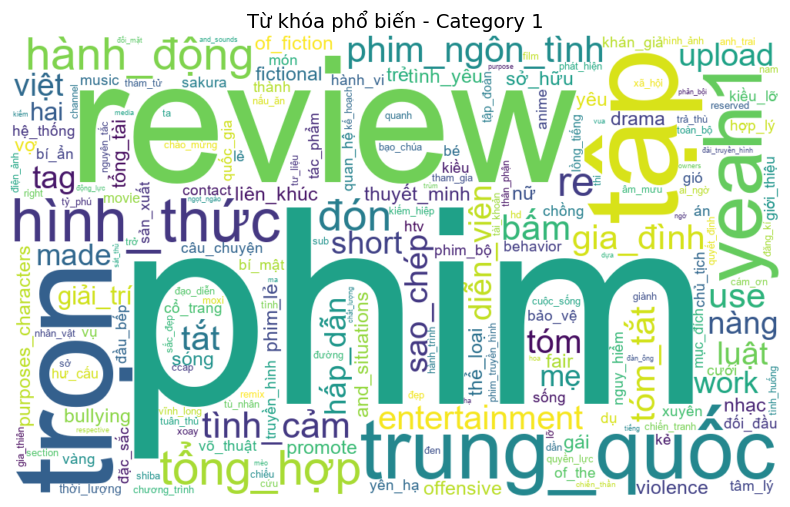

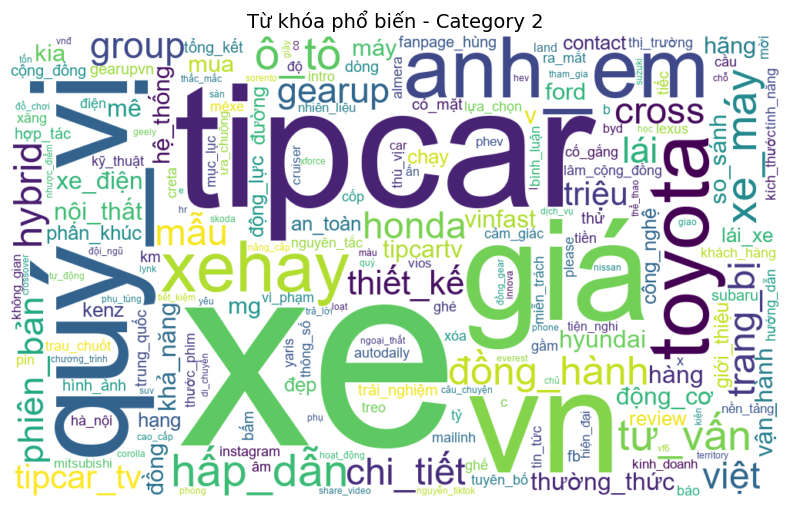

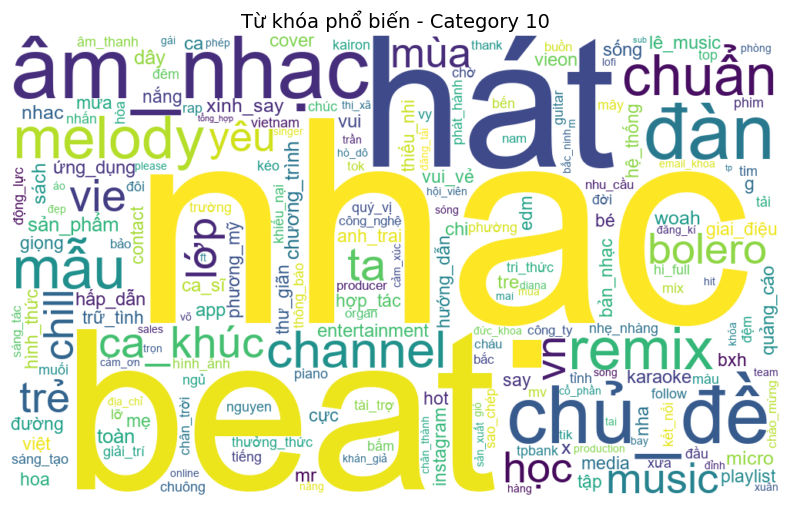

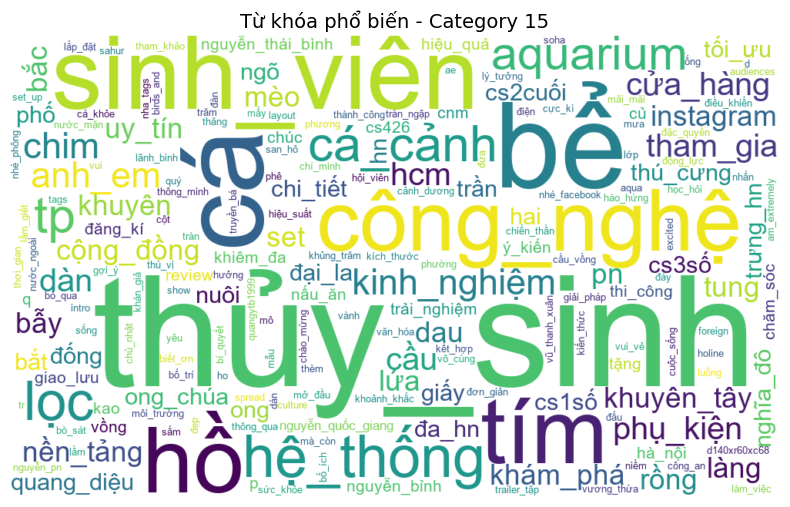

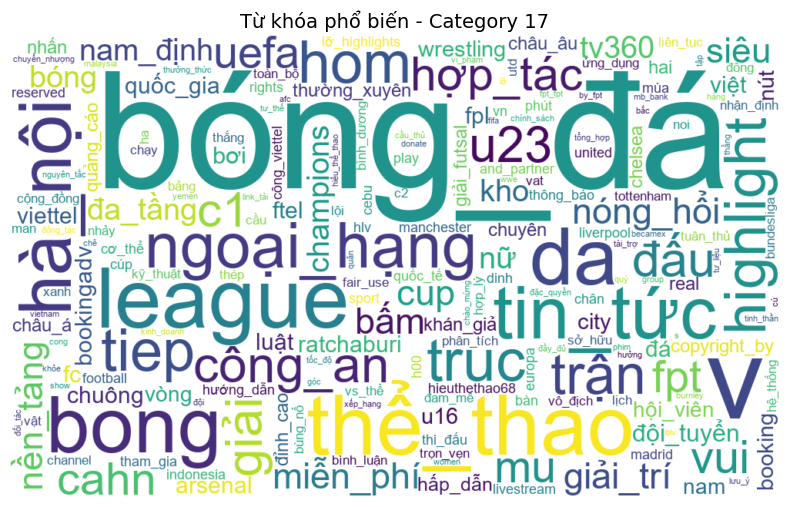

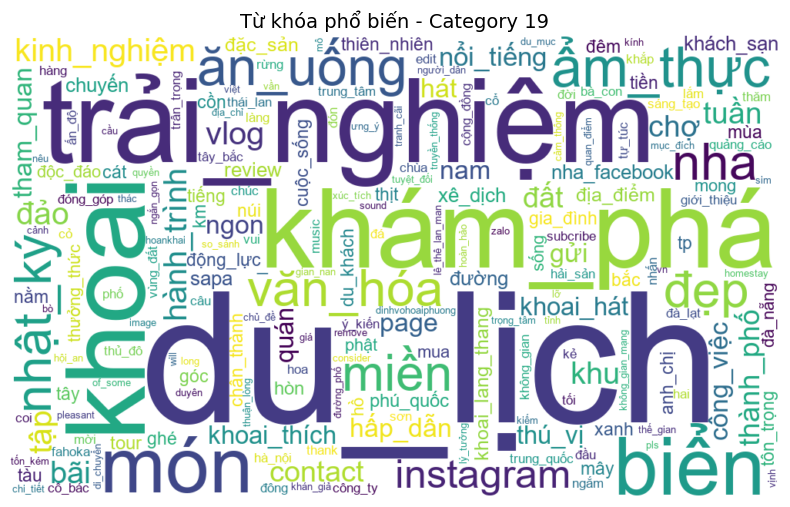

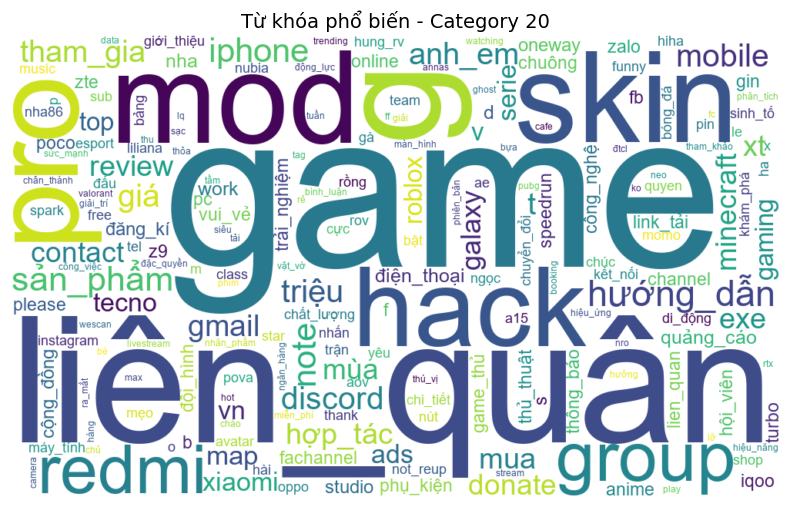

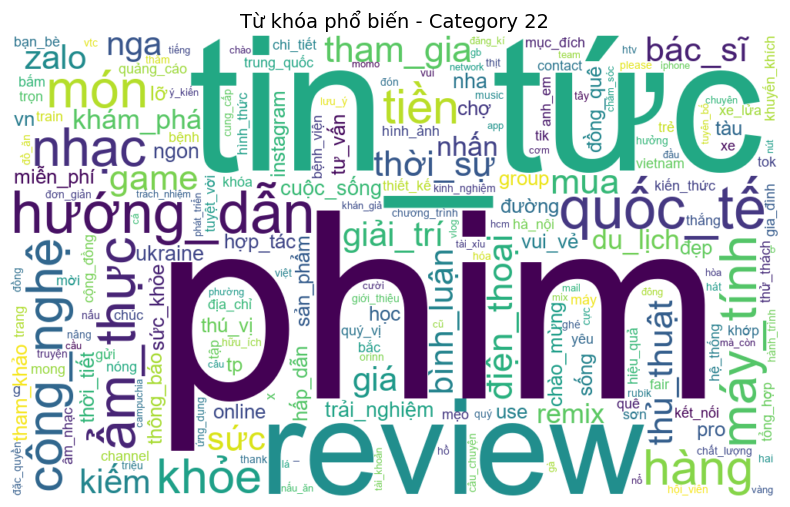

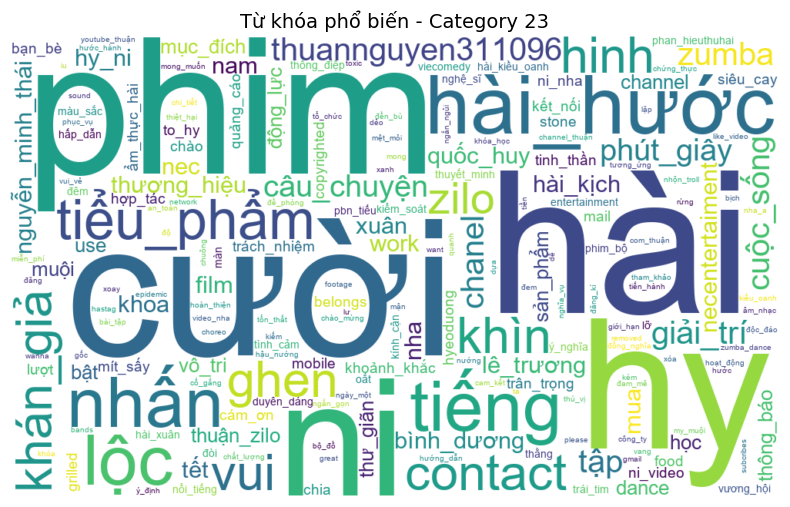

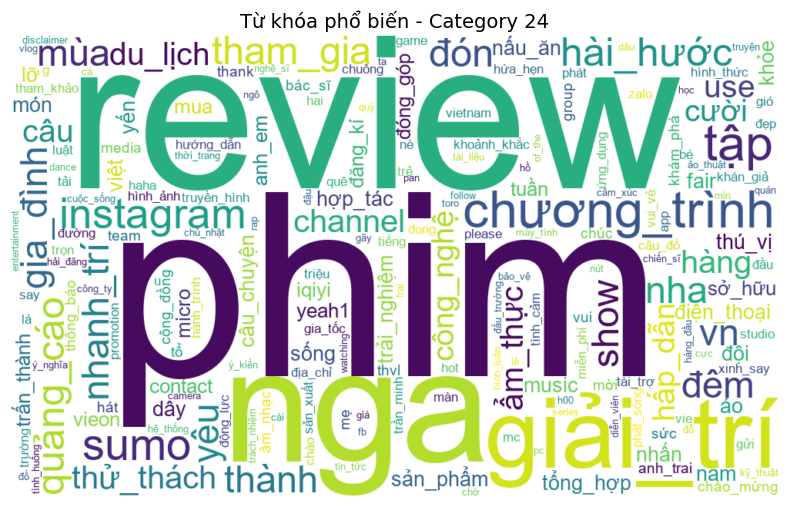

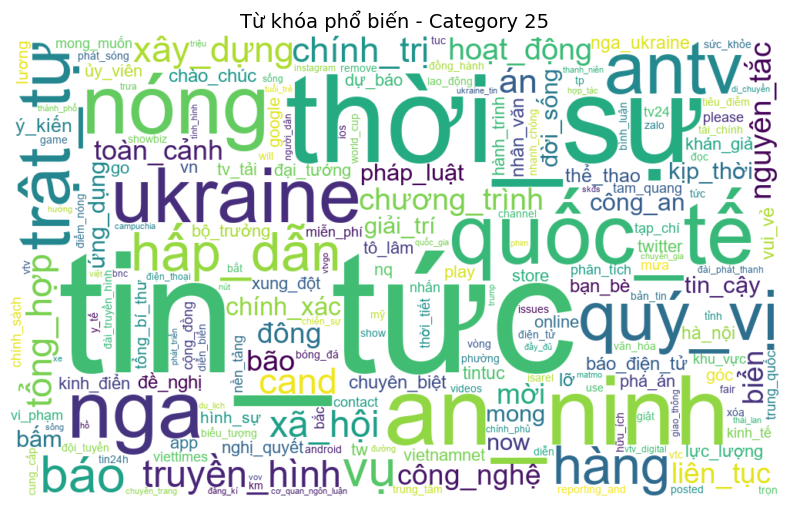

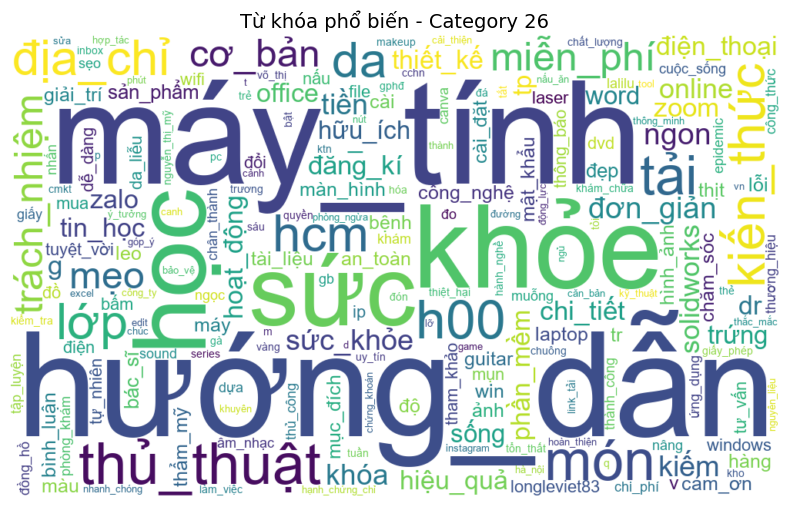

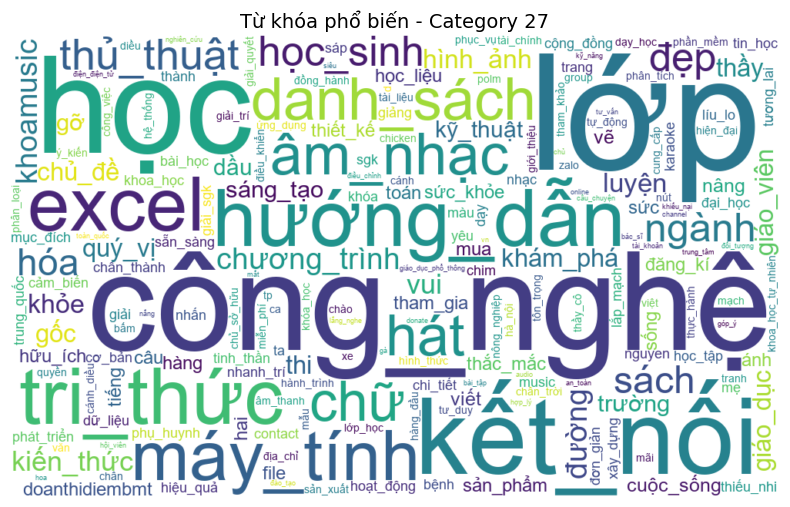

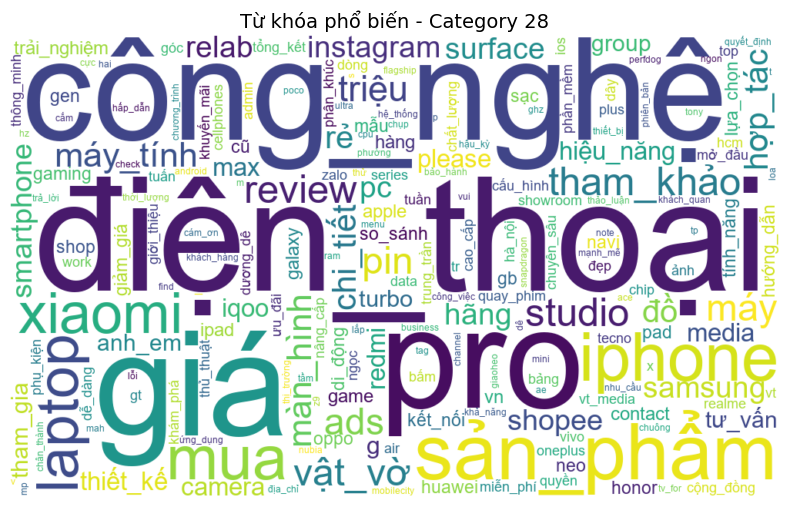

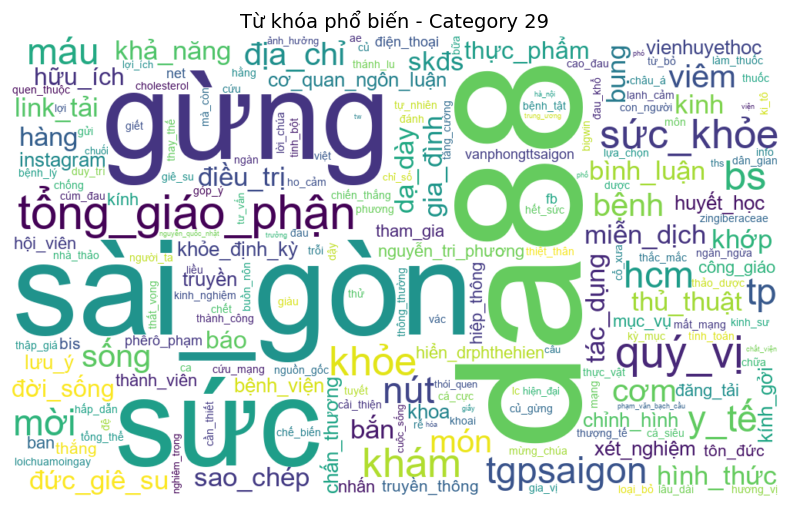

In [5]:
for cat in sorted(df["category_id"].unique()):
    subset = " ".join(df[df["category_id"] == cat]["tokenized_text"])
    if len(subset) > 50:
        wc = WordCloud(width=1000, height=600, background_color="white", font_path="arial.ttf",
                       collocations=False, max_words=200).generate(subset)
        plt.figure(figsize=(10,6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Từ khóa phổ biến - Category {cat}", fontsize=14)
        plt.show()


In [14]:
category_stopwords = {
    # ===== 1. Film & Animation =====
    1: {
        "review", "tag", "yeah", "use", "contact", "gia_đình", "channel",
        "link", "subscribe", "vie_channel", "fair", "use", "upload", "copyright"
    },

    # ===== 2. Autos & Vehicles =====
    2: {
        "contact", "fanpage", "tv", "youtube", "share", "tipcartv", "tipcarvn",
        "mailinh", "xehay", "gearup", "review", "subscribe", "channel"
    },

    # ===== 10. Music =====
    10: {
        "vie_channel", "contact", "email", "follow", "subscribe", "tải", "woah",
        "channel", "music", "like", "comment", "official"
    },

    # ===== 15. Pets & Animals =====
    15: {
        "tp_hcm", "tham_gia", "cộng_đồng", "hiệu_quả", "cs426", "pn", "cnm",
        "khuyến", "tặng", "đăng_ký", "review", "thủy_sinh_việt", "contact","sinh_viên","công_nghệ"
    },

    # ===== 17. Sports =====
    17: {
        "miễn_phí", "booking", "ftel", "link", "fanpage", "fair_use", "network",
        "tv360", "copyright", "channel", "đăng_ký"
    },

    # ===== 19. Travel & Events =====
    19: {
        "page", "instagram", "facebook", "vlog", "hashtag", "ntit", "image",
        "khoai", "contact", "follow", "subscribe", "channel"
    },

    # ===== 20. Gaming =====
    20: {
        "gmail", "work", "contact", "ads", "redmi", "note", "xiaomi", "galaxy",
        "group", "discord", "donate", "link", "anh_em", "mod", "subscribe"
    },

    # ===== 22. People & Blogs =====
    22: {
        "click", "subscribe", "link", "fanpage", "fair_use", "contact_us",
        "review", "channel", "phim", "tiktok", "facebook"
    },

    # ===== 23. Comedy =====
    23: {
        "contact", "gmail", "channel", "network", "share", "mobile", "zumba",
        "zilo", "thuannguyen311096", "vui", "film", "subscribe"
    },

    # ===== 24. Entertainment =====
    24: {
        "fair", "use", "contact", "channel", "vie_channel", "subscribe",
        "please", "contact_us", "sumo", "thành", "team", "yeah1", "review"
    },

    # ===== 25. News & Politics =====
    25: {
        "mời_quý_vị", "chúc", "bấm", "app_store", "google_play", "and", "in",
        "play", "app", "quý_vị", "antv", "truyền_hình", "cand", "channel"
    },

    # ===== 26. HowTo & Style =====
    26: {
        "zoom", "office", "tải", "miễn_phí", "đăng_ký", "channel", "subscribe",
        "contact", "zalo", "gmail", "fanpage", "like", "share", "facebook"
    },

    # ===== 27. Education =====
    27: {
        "miễn_phí", "sức_khỏe", "khám", "fanpage", "contact", "channel",
        "đăng_ký", "zalo", "facebook", "subscribe", "excel", "khoamusic"
    },

    # ===== 28. Science & Technology =====
    28: {
        "contact", "ads", "studio", "vật_vỡ", "fanpage", "subscribe",
        "official", "review", "iphone", "xiaomi", "relab", "instagram", "shopee"
    },

    # ===== 29. Nonprofits & Activism =====
    29: {
        "da88", "casino", "bắn_cá", "game", "link", "fair_use", "subscribe",
        "contact", "fanpage", "tổng_giáo_phận", "tgp", "tp", "hcm", "sg"
    },
}

print(f"Đã khởi tạo {len(category_stopwords)} bộ stopwords tùy chỉnh cho từng category.")


Đã khởi tạo 15 bộ stopwords tùy chỉnh cho từng category.


In [15]:
def remove_category_stopwords(row):
    """Loại bỏ stopwords riêng cho từng category."""
    text = row["tokenized_text"]
    cat = row["category_id"]

    # Lấy stopwords tương ứng category (nếu có)
    sw = category_stopwords.get(cat, set())

    # Loại stopwords
    cleaned = " ".join([w for w in text.split() if w not in sw])
    return cleaned

In [16]:
# Áp dụng lọc stopword theo từng category
df["tokenized_text"] = df.apply(remove_category_stopwords, axis=1)
print("Đã loại bỏ stopwords riêng theo từng category thành công.")

Đã loại bỏ stopwords riêng theo từng category thành công.


In [17]:
from collections import Counter
for cat in sorted(df["category_id"].unique()):
    subset = df[df["category_id"] == cat]["tokenized_text"]
    words = " ".join(subset).split()
    common = Counter(words).most_common(10)
    print(f"Category {cat}: {common[:10]}")

Category 1: [('phim', 1555), ('trọn', 243), ('tập', 213), ('trung_quốc', 147), ('yeah1', 142), ('hình_thức', 140), ('tổng_hợp', 113), ('hành_động', 102), ('đón', 95), ('re', 85)]
Category 2: [('xe', 627), ('tipcar', 186), ('vn', 131), ('giá', 121), ('quý_vị', 110), ('anh_em', 106), ('toyota', 102), ('hấp_dẫn', 88), ('ô_tô', 86), ('xe_máy', 84)]
Category 10: [('nhạc', 482), ('beat', 271), ('hát', 208), ('âm_nhạc', 196), ('chủ_đề', 164), ('đàn', 157), ('melody', 140), ('remix', 139), ('mẫu', 137), ('chuẩn', 131)]
Category 15: [('thủy_sinh', 26), ('bể', 14), ('cá', 13), ('hồ', 8), ('tím', 8), ('hệ_thống', 7), ('lọc', 6), ('tp', 5), ('cá_cảnh', 5), ('aquarium', 5)]
Category 17: [('bóng_đá', 1459), ('vs', 505), ('thể_thao', 278), ('league', 277), ('da', 249), ('bong', 246), ('25', 230), ('k', 224), ('tin_tức', 214), ('hà_nội', 210)]
Category 19: [('du_lịch', 596), ('trải_nghiệm', 168), ('khám_phá', 162), ('biển', 132), ('món', 127), ('ẩm_thực', 121), ('ăn_uống', 114), ('nha', 100), ('văn_hó




1. FILM & ANIMATION (Phim và Hoạt hình)
   - Video phim, review phim, trailer, anime, hoạt hình, phân tích nội dung điện ảnh.

2. AUTOS & VEHICLES (Xe cộ và Phương tiện)
   - Review ô tô, xe máy, công nghệ xe, hãng xe (Toyota, Honda...), hướng dẫn lái, độ xe.

10  MUSIC (Âm nhạc)
   - Bài hát, MV, karaoke, remix, cover, beat, nhạc cụ, bolero, pop, rap, EDM.

15. PETS & ANIMALS (Động vật & Thú cưng)
   - Thủy sinh, nuôi cá cảnh, chăm sóc mèo, chó, sinh vật cảnh, thú y.

17. SPORTS (Thể thao)
   - Bóng đá, bóng rổ, võ thuật, giải đấu (U23, Premier League...), highlights, bình luận thể thao.

19. TRAVEL & EVENTS (Du lịch & Sự kiện)
   - Review du lịch, khám phá, trải nghiệm, ẩm thực vùng miền, vlog du lịch, homestay.

20. GAMING (Trò chơi điện tử)
   - Game mobile/PC (Liên Quân, Roblox, Free Fire...), hướng dẫn, mod, skin, donate, cộng đồng game.

22. PEOPLE & BLOGS (Cá nhân & Blog)
   - Vlog đời sống, chia sẻ cá nhân, trải nghiệm, nhật ký, các video không thuộc lĩnh vực cụ thể.

23. COMEDY (Hài hước & Giải trí ngắn)
   - Video hài, tấu hài, parody, tiểu phẩm, clip vui, giải trí nhẹ.

24. ENTERTAINMENT (Giải trí tổng hợp)
   - Gameshow, TV show, talkshow, chương trình truyền hình, sự kiện giải trí, review showbiz.

25. NEWS & POLITICS (Tin tức & Chính trị)
   - Thời sự, quốc tế, chính trị, an ninh, xã hội, bình luận tin tức, báo chí.

26. HOWTO & STYLE (Hướng dẫn & Phong cách sống)
   - Video hướng dẫn kỹ năng, thủ thuật, làm đẹp, DIY, sức khỏe, mẹo vặt, đời sống.

27. EDUCATION (Giáo dục & Học tập)
   - Dạy học, học sinh, bài giảng, kiến thức, học Excel, tin học, kỹ năng mềm.

28. SCIENCE & TECHNOLOGY (Khoa học & Công nghệ)
   - Review công nghệ, điện thoại, laptop, thiết bị số, thử nghiệm khoa học, nghiên cứu kỹ thuật.

29. NONPROFITS & ACTIVISM (Tổ chức phi lợi nhuận & Hoạt động xã hội)
   - Video tôn giáo, từ thiện, sức khỏe cộng đồng, tổ chức xã hội, nhân đạo, giáo hội.







In [19]:
import os
output_dir = r"D:\22DKHA1\project\projeet 2"
output_path = os.path.join(output_dir, "youtube_clean_final.csv")

# Tạo thư mục nếu chưa tồn tại
os.makedirs(output_dir, exist_ok=True)

# Lưu file CSV (chuẩn UTF-8, mở được trong Excel)
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Đã lưu file dữ liệu sạch tại: {output_path}")
print(f"Tổng số dòng sau khi làm sạch: {len(df)}")

Đã lưu file dữ liệu sạch tại: D:\22DKHA1\project\projeet 2\youtube_clean_final.csv
Tổng số dòng sau khi làm sạch: 6752


In [2]:
import pandas as pd
import os

# Đường dẫn đến file đã làm sạch
clean_path = r"D:\22DKHA1\project\projeet 2\youtube_clean_final.csv"

# Kiểm tra xem file có tồn tại không
if os.path.exists(clean_path):
    df = pd.read_csv(clean_path, encoding="utf-8-sig")
    print("Đã đọc dữ liệu sạch thành công!")
    print(f"Số dòng dữ liệu: {len(df)}")
    print(f"Các cột hiện có: {list(df.columns)}")
else:
    print("File youtube_clean_final.csv chưa tồn tại. Vui lòng chạy lại phần tiền xử lý trước.")

Đã đọc dữ liệu sạch thành công!
Số dòng dữ liệu: 6752
Các cột hiện có: ['title', 'description', 'category_id', 'clean_text', 'tokenized_text']


In [3]:
print("Các cột:", list(df.columns))
print("Số dòng:", len(df))
df.head()


Các cột: ['title', 'description', 'category_id', 'clean_text', 'tokenized_text']
Số dòng: 6752


,title,description,category_id,clean_text,tokenized_text
0,Hướng Dẫn chậm 4 bước CHA CHA CHA cơ bản cho n...,💥💥💥ĐÂY LÀ LINK VIDEO RÁP ĐỘNG TÁC VỚI NHẠC: 💥 ...,26,đây là link video ráp động tác với nhạc em lại...,ráp_động_tác nhạc hiện tuyển_sinh lớp nhảy onl...
1,HƯỚNG DẪN CHẬM NHẢY KHIÊU VŨ BACHATA [ Hướng D...,Khiêu vũ bachata [ Hướng Dẫn Khiêu Vũ - Dân Vũ...,22,khiêu vũ bachata hướng dẫn khiêu vũ dân vũ cho...,khiêu vũ_bachata hướng_dẫn khiêu_vũ dân_vũ tập
2,Hướng Dẫn Ăn Chân Gà Chanh Sao Cho Đúng Cách! ...,Hướng Dẫn Ăn Chân Gà Chanh Sao Cho Đúng Cách! ...,22,hướng dẫn ăn chân gà chanh sao cho đúng cách t...,hướng_dẫn chân gà chanh tuyển_tập tạp_hóa đồ_ă...
3,VŨ ĐIỆU KẾT ĐOÀN - HƯỚNG DẪN DỄ HIỂU & NGẮN GỌ...,Đăng kí kênh để ủng hộ mình nhé! Chúc bạn xem ...,22,đăng kí kênh để ủng hộ mình nhé chúc bạn xem v...,đăng_kí chúc vui_vẻ nhảy_mẫu
4,Nhạc Chậm - XIN CHÀO 34 TỈNH THÀNH // biên đạo...,bài hướng dẫn chi tiết 👉 https://youtu.be/7fDz...,22,bài hướng dẫn chi tiết,hướng_dẫn chi_tiết


In [4]:


# Kiểm tra thông tin chung
print("\nThông tin dữ liệu:")
print(df.info())

# Kiểm tra các giá trị null
print("\nKiểm tra giá trị trống:")
print(df.isnull().sum())


Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6752 entries, 0 to 6751
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           6752 non-null   object
 1   description     6752 non-null   object
 2   category_id     6752 non-null   int64 
 3   clean_text      6752 non-null   object
 4   tokenized_text  6750 non-null   object
dtypes: int64(1), object(4)
memory usage: 263.9+ KB
None

Kiểm tra giá trị trống:
title             0
description       0
category_id       0
clean_text        0
tokenized_text    2
dtype: int64


In [5]:
# Xóa các dòng bị thiếu tokenized_text
df = df.dropna(subset=["tokenized_text"])
print("Sau khi xóa dòng thiếu, còn lại:", len(df))

Sau khi xóa dòng thiếu, còn lại: 6750


In [6]:
output_path = r"D:\22DKHA1\project\projeet 2\youtube_clean_final_fixed.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")
print("Đã lưu dữ liệu ổn định tại:", output_path)

Đã lưu dữ liệu ổn định tại: D:\22DKHA1\project\projeet 2\youtube_clean_final_fixed.csv


In [7]:
check = pd.read_csv(output_path, encoding="utf-8-sig")
print("Đọc lại file vừa lưu:", len(check), "dòng")
check.head()


Đọc lại file vừa lưu: 6750 dòng


,title,description,category_id,clean_text,tokenized_text
0,Hướng Dẫn chậm 4 bước CHA CHA CHA cơ bản cho n...,💥💥💥ĐÂY LÀ LINK VIDEO RÁP ĐỘNG TÁC VỚI NHẠC: 💥 ...,26,đây là link video ráp động tác với nhạc em lại...,ráp_động_tác nhạc hiện tuyển_sinh lớp nhảy onl...
1,HƯỚNG DẪN CHẬM NHẢY KHIÊU VŨ BACHATA [ Hướng D...,Khiêu vũ bachata [ Hướng Dẫn Khiêu Vũ - Dân Vũ...,22,khiêu vũ bachata hướng dẫn khiêu vũ dân vũ cho...,khiêu vũ_bachata hướng_dẫn khiêu_vũ dân_vũ tập
2,Hướng Dẫn Ăn Chân Gà Chanh Sao Cho Đúng Cách! ...,Hướng Dẫn Ăn Chân Gà Chanh Sao Cho Đúng Cách! ...,22,hướng dẫn ăn chân gà chanh sao cho đúng cách t...,hướng_dẫn chân gà chanh tuyển_tập tạp_hóa đồ_ă...
3,VŨ ĐIỆU KẾT ĐOÀN - HƯỚNG DẪN DỄ HIỂU & NGẮN GỌ...,Đăng kí kênh để ủng hộ mình nhé! Chúc bạn xem ...,22,đăng kí kênh để ủng hộ mình nhé chúc bạn xem v...,đăng_kí chúc vui_vẻ nhảy_mẫu
4,Nhạc Chậm - XIN CHÀO 34 TỈNH THÀNH // biên đạo...,bài hướng dẫn chi tiết 👉 https://youtu.be/7fDz...,22,bài hướng dẫn chi tiết,hướng_dẫn chi_tiết
